In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from src_gypsum import utils
import flopy

In [2]:
# Cargamos el modelo de flujo
o_sim = flopy.mf6.MFSimulation.load(
    sim_ws="io_mf6/gwf_gwt_comp",
    verbosity_level=0)

# Obtenemos el objetos del modelo
o_gwt = o_sim.get_model("transport")

# Recuperamos las coordenadas del dominio
grid = o_gwt.modelgrid

# Recuperamos las coordenadas de los centros de las celdas de la malla
x = grid.xcellcenters[0] # centros de los volúmenes
print(x)

times = ["10d", "20d", "30d", "40d"]
print(times)

[ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5]
['10d', '20d', '30d', '40d']


In [4]:
nspec = 3
#
# Leer información de "u_init.dat"
with open("rt_workingDir/u_init_yeso.dat", "r") as f:
    spec_info = f.readlines()
key_string = "  Aqueous variable activity species:"
isp = utils.find_index(spec_info, key_string, 1)
spec_names = [l.split(": ")[1].strip() for l in spec_info[isp:isp+nspec]]
print(spec_names)

#
# Leer información de la simulación 
with open("rt_workingDir/gypsum_final_species.dat", "r") as f:
    lines = f.readlines()
steps = len(lines) // nspec
print(steps)

['ca+2', 'cl-', 'so4-2']
41


In [7]:
lines[2]

'0.00 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 1.64691e-07 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 3.29371e-05 \n'

['ca+2', 'cl-', 'so4-2']


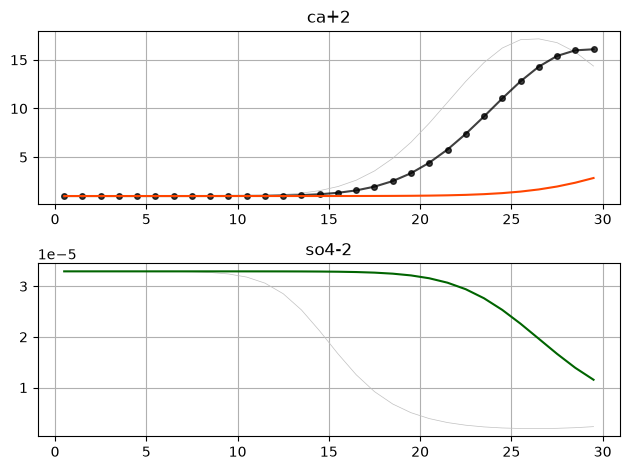

In [11]:
fig, ax = plt.subplots(2, 1)

print(f"{spec_names}")

#ax[0].plot(x, [float(l) for l in lines[0].split()][1:], lw=1.5, ls = "-", color='C1')
#ax[1].plot(x, [float(l) for l in lines[2].split()][1:], lw=1.5, ls = "-", color='C2')

for nt in range(1, 2, 1):
    ax[0].plot(x, [float(l) for l in lines[0 + nt * nspec].split()][1:], lw=.5, color='silver')
    ax[1].plot(x, [float(l) for l in lines[2 + nt * nspec].split()][1:], lw=.5, color='silver')

ax[0].plot(x, [float(l) for l in lines[24].split()][1:], lw=1.5, ls = "-", color='black',
          marker = "o", markersize="4", alpha = 0.75)

ax[0].plot(x, [float(l) for l in lines[-3].split()][1:], lw=1.5, ls = "-", color='orangered')
ax[1].plot(x, [float(l) for l in lines[-1].split()][1:], lw=1.5, ls = "-", color='darkgreen')

ax[0].set_title(f"{spec_names[0]}")
ax[1].set_title(f"{spec_names[2]}")

ax[0].grid()
ax[1].grid()

plt.tight_layout()
plt.savefig("componentes_yeso.png")
plt.show()